In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

from datetime import datetime as dt

%matplotlib inline

path = "/Users/emiller/Documents/sf_tech/sf_datasets/"

amzn_cat_csv = pd.read_csv(path + "amazon_categories.csv")
amzn_prod_csv = pd.read_csv(path + "amazon_products.csv")


pd.set_option('display.max_columns', None)

print('complete')

complete


In [3]:
amzn_merged_csv = pd.merge(amzn_cat_csv, amzn_prod_csv, left_on='id', right_on='category_id', how='inner')

In [4]:
# drop columns that are not needed, and make column names lowercase

drop_cols = ['id', 'imgUrl', 'productURL']

amzn_merged_df = amzn_merged_csv.drop(drop_cols, axis='columns')

amzn_merged_df = (
    amzn_merged_df.rename(columns=str.lower)
    .rename(columns={'listprice': 'list_price', 'isbestseller': 'best_seller', 'boughtinlastmonth': 'bought_in_last_month'})
    )


## EDA

In [5]:
""" clean columns """
# price and list price to coalesce each other
amzn_merged_df['list_price'] = np.where(amzn_merged_df['list_price'] == 0, amzn_merged_df['price'], amzn_merged_df['list_price'])

# create discount column from price and list price
amzn_merged_df['discount_rate'] = (
    (amzn_merged_df['list_price'] - amzn_merged_df['price']) / amzn_merged_df['list_price']
)


# 'category' dummy variables? top 10 unique values from amazon_cat_csv
top_cats = amzn_merged_df.category_name.value_counts().nlargest(10).index
amzn_merged_df['category_group'] = (amzn_merged_df['category_name']
                                    .where(amzn_merged_df['category_name'].isin(top_cats), 'other'))

amzn_merged_df['category_group'] = (
    amzn_merged_df['category_group']
    .str.replace(' ', '_')
    .str.replace("'", '')
    .str.replace('&', 'and')
    .str.lower()
)


# amzn_merged_df.category_group.value_counts().head(20)

# get dummies
amzn_dummies_df = pd.get_dummies(amzn_merged_df.category_group)
amzn_df = amzn_merged_df.join(amzn_dummies_df)
amzn_df.head()

# remove columns: ['asin', 'title', 'category_id', 'category_name'] + 1 of the 'category' values
drops = ['asin', 'title', 'category_id', 'category_name', 'other']
amzn_df.drop(drops, axis='columns', inplace=True)



In [6]:
amzn_df.head()

,stars,reviews,price,list_price,best_seller,bought_in_last_month,discount_rate,category_group,boys_clothing,girls_clothing,girls_jewelry,mens_accessories,mens_clothing,mens_shoes,toys_and_games,womens_clothing,womens_handbags,womens_jewelry
0,4.7,510,9.99,9.99,False,50,0.0,other,False,False,False,False,False,False,False,False,False,False
1,4.6,584,8.99,8.99,False,0,0.0,other,False,False,False,False,False,False,False,False,False,False
2,4.5,245,12.79,12.79,False,50,0.0,other,False,False,False,False,False,False,False,False,False,False
3,5.0,1,16.99,16.99,False,0,0.0,other,False,False,False,False,False,False,False,False,False,False
4,4.4,10,15.99,15.99,False,50,0.0,other,False,False,False,False,False,False,False,False,False,False


In [11]:
"""
calculate:
mean, median, quintiles
of:
price, list_price, diff(price, list_price), reviews, number of stars
also:
% best sellers, % of purchases with discounts
for:
products as a whole
product categories
"""
# ############## For Products
# descriptive stats for 
ntiles = [0.2, 0.4, 0.6, 0.8]
amzn_df[['price', 'list_price', 'discount_rate', 'reviews', 'stars']].describe(percentiles=ntiles)

# percentage best sellers
len(amzn_df[amzn_df['best_seller'] == True]) / len(amzn_df)

# percentage of purchases with discounts
len(amzn_df[amzn_df['discount_rate'] > 0]) / len(amzn_df)

# amzn_df.head()




0.24198699185395878

In [12]:
####### For Categories

# descriptive stats
amzn_df.groupby('category_group').describe()

# percentage best sellers
amzn_df.groupby('category_group')['best_seller'].mean()

# percentage w/ reviews
(amzn_df['reviews'] > 0).groupby(amzn_df['category_group']).mean()

# percentage of purchases with discounts
(amzn_df['discount_rate'] != 0).groupby(amzn_df['category_group']).mean()

# best sellers w/ bought in last month

# discount w/ bought in last month

# category w/ bought in last month



category_group
boys_clothing       0.248337
girls_clothing      0.213844
girls_jewelry       0.081182
mens_accessories    0.239833
mens_clothing       0.324734
mens_shoes          0.433206
other               0.265864
toys_and_games      0.327113
womens_clothing     0.352268
womens_handbags     0.238075
womens_jewelry      0.164363
Name: discount_rate, dtype: float64

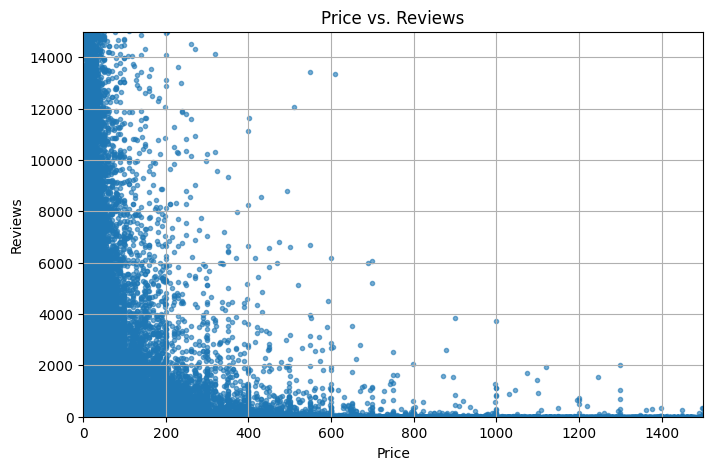

In [13]:
"""
graphs - line (products & categories):
"""
import matplotlib.pyplot as plt

# PRICE VS REVIEWS
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['price'], amzn_df['reviews'], marker='.', alpha=0.6)
plt.xlim(0, 1500)     # Set x-axis range
plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Price')
plt.ylabel('Reviews')
plt.title('Price vs. Reviews')
plt.grid(True)
plt.show()



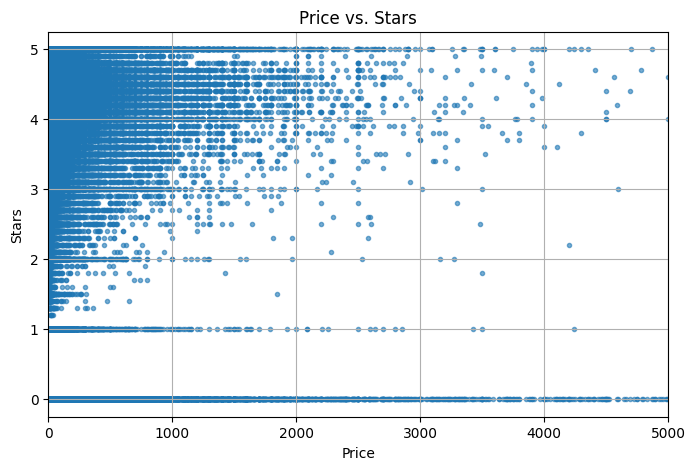

In [14]:
# PRICE VS STARS
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['price'], amzn_df['stars'], marker='.', alpha=0.6)
plt.xlim(0, 5000)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Price')
plt.ylabel('Stars')
plt.title('Price vs. Stars')
plt.grid(True)
plt.show()

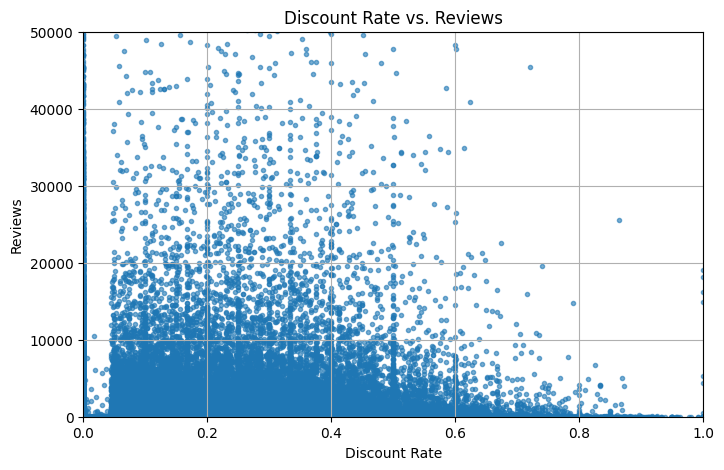

In [15]:
# DISCOUNT RATE VS REVIEWS
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['discount_rate'], amzn_df['reviews'], marker='.', alpha=0.6)
plt.xlim(0, 1.0)     # Set x-axis range
plt.ylim(0, 50000)       # Set y-axis range
plt.xlabel('Discount Rate')
plt.ylabel('Reviews')
plt.title('Discount Rate vs. Reviews')
plt.grid(True)
plt.show()

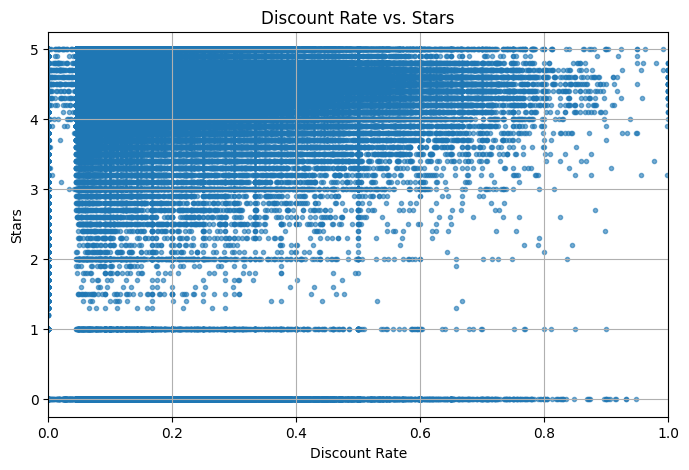

In [16]:
# DISCOUNT RATE VS STARS
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['discount_rate'], amzn_df['stars'], marker='.', alpha=0.6)
plt.xlim(0, 1.0)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Discount Rate')
plt.ylabel('Stars')
plt.title('Discount Rate vs. Stars')
plt.grid(True)
plt.show()

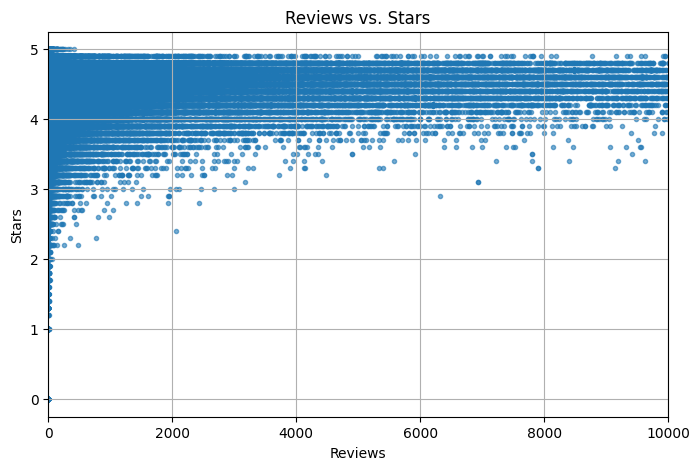

In [17]:
# REVIEWS VS STARS
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['reviews'], amzn_df['stars'], marker='.', alpha=0.6)
plt.xlim(0, 10000)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Reviews')
plt.ylabel('Stars')
plt.title('Reviews vs. Stars')
plt.grid(True)
plt.show()

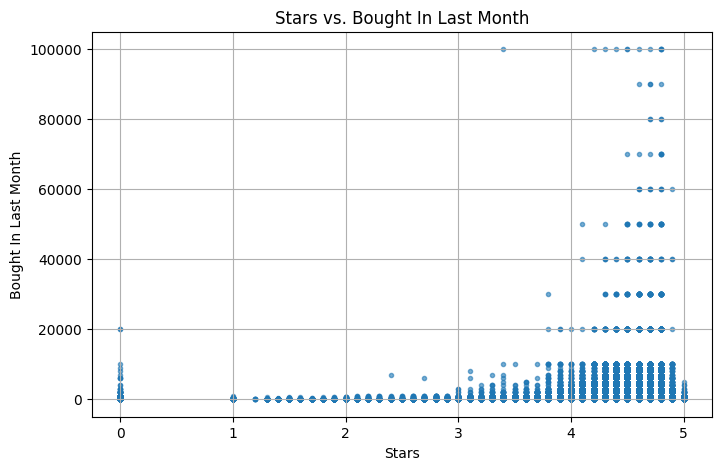

In [18]:
# STARS VS BOUGHT_IN_LAST_MONTH
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['stars'], amzn_df['bought_in_last_month'], marker='.', alpha=0.6)
# plt.xlim(0, 10000)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Stars')
plt.ylabel('Bought In Last Month')
plt.title('Stars vs. Bought In Last Month')
plt.grid(True)
plt.show()

#### Data Transformations

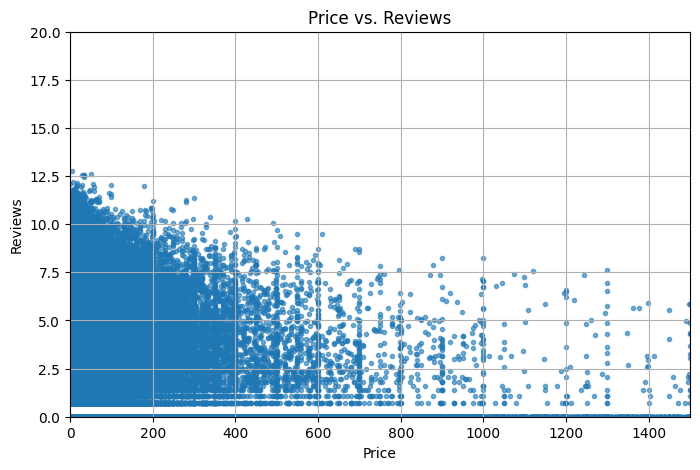

In [ ]:
"""
PRICE VS LOG(REVIEWS)

-- applying a log transformation successfully transformed the relationship into one that was more linear
-- linear regression can be applied with new output
"""


amzn_df['log_reviews'] = np.log1p(amzn_df['reviews'])


# PRICE VS LOG(REVIEWS)
plt.figure(figsize=(8, 5))
# plt.scatter(amzn_df['price'], amzn_df['reviews'], marker='.', alpha=0.6)
plt.scatter(amzn_df['price'], amzn_df['log_reviews'], marker='.', alpha=0.6)

plt.xlim(0, 1500)     # Set x-axis range
plt.ylim(0, 20)       # Set y-axis range
plt.xlabel('Price')
plt.ylabel('Reviews')
plt.title('Price vs. log(Reviews)')
plt.grid(True)
plt.show()

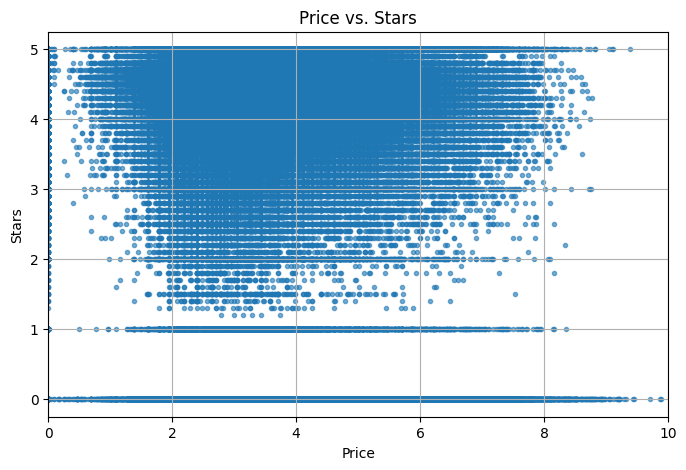

In [ ]:
"""
LOG(PRICE) VS STARS

-- applying a log transformation made the data more compact, but did not create a linear relationship
-- compare linear regression with gradient boosting

When presenting this:
	1.	Show before and after transformation plots — highlight how log scaling improves interpretability.
	2.	Mention that this transformation helps avoid model bias from extreme price outliers.
"""

amzn_df['log_price'] = np.log1p(amzn_df['price'])

# PRICE VS STARS
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['log_price'], amzn_df['stars'], marker='.', alpha=0.6)
plt.xlim(0, 10)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Price')
plt.ylabel('Stars')
plt.title('log(Price) vs. Stars')
plt.grid(True)
plt.show()

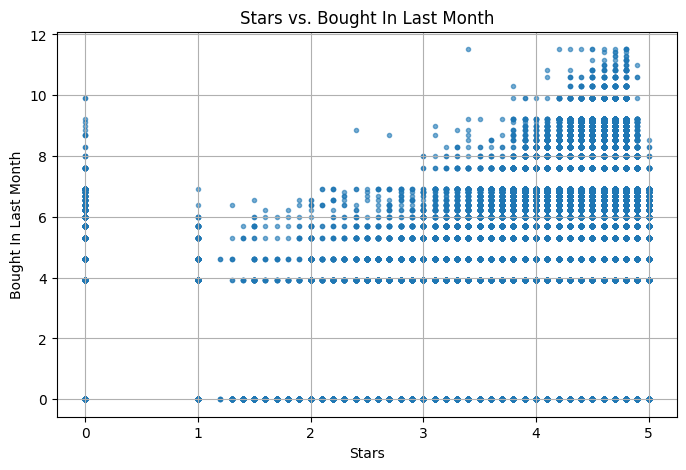

In [ ]:
"""
STARS VS LOG(BOUGHT IN LAST MONTH)

-- applied log transformation - did not yield meaningful change
"""

amzn_df['log_bought_in_last_month'] = np.log1p(amzn_df['bought_in_last_month'])

# STARS VS BOUGHT_IN_LAST_MONTH
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['stars'], amzn_df['log_bought_in_last_month'], marker='.', alpha=0.6)
# plt.xlim(0, 10000)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Stars')
plt.ylabel('Bought In Last Month')
plt.title('Stars vs. Log(Bought In Last Month)')
plt.grid(True)
plt.show()

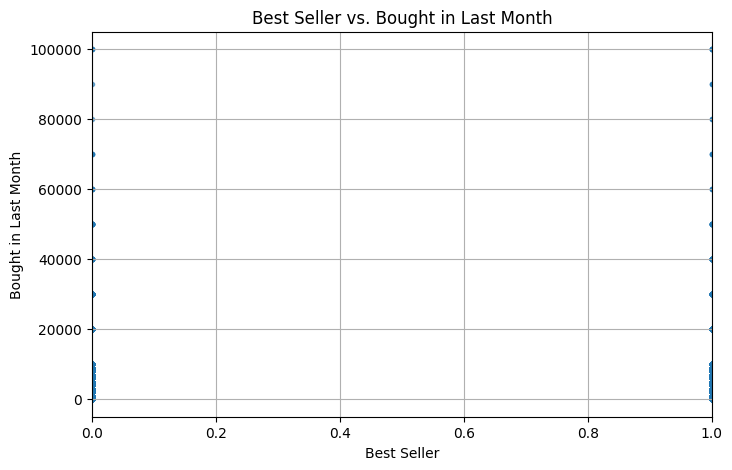

In [10]:
"""
BEST SELLER VS BOUGHT IN LAST MONTH
"""

# amzn_df['log_reviews'] = np.log1p(amzn_df['reviews'])

# BEST SELLER VS BOUGHT IN LAST MONTH
plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['best_seller'], amzn_df['bought_in_last_month'], marker='.', alpha=0.6)
plt.xlim(0, 1)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Best Seller')
plt.ylabel('Bought in Last Month')
plt.title('Best Seller vs. Bought in Last Month')
plt.grid(True)
plt.show()

In [ ]:
# (amzn_df[amzn_df['discount_rate'] < 0]).head()

,stars,reviews,price,list_price,best_seller,boughtinlastmonth,discount_rate,category_group,boys_clothing,girls_clothing,girls_jewelry,mens_accessories,mens_clothing,mens_shoes,toys_and_games,womens_clothing,womens_handbags,womens_jewelry
8461,4.4,115,20.99,19.99,False,50,-0.050025,other,False,False,False,False,False,False,False,False,False,False
63030,4.7,0,11.26,11.22,False,800,-0.003565,other,False,False,False,False,False,False,False,False,False,False
65576,4.5,0,15.68,15.00,False,200,-0.045333,other,False,False,False,False,False,False,False,False,False,False
70140,4.8,0,6.95,6.49,False,0,-0.070878,other,False,False,False,False,False,False,False,False,False,False
102248,5.0,0,44.21,36.40,False,0,-0.214560,other,False,False,False,False,False,False,False,False,False,False


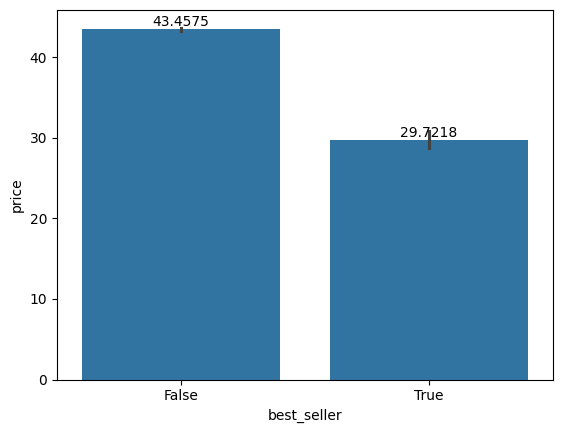

In [16]:
"""
BAR GRAPH of best_seller vs price
"""

ax = sns.barplot(x="best_seller", y="price", data=amzn_df)
ax.bar_label(ax.containers[0])  # adds labels automatically
plt.show()

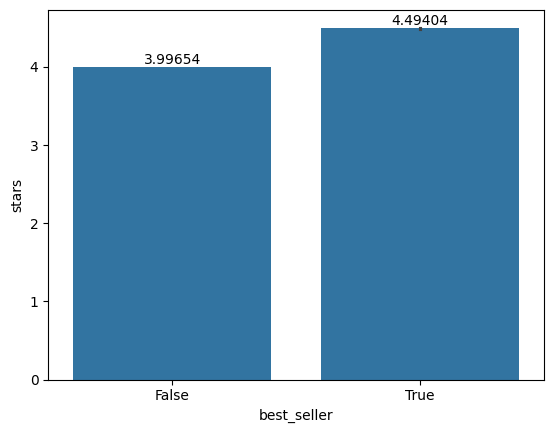

In [15]:
import seaborn as sns

ax = sns.barplot(x="best_seller", y="stars", data=amzn_df)
ax.bar_label(ax.containers[0])  # adds labels automatically
plt.show()

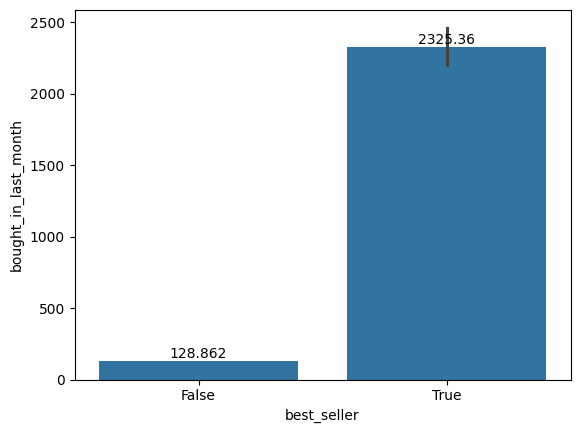

In [17]:
"""
BAR GRAPH of best_seller vs bought_in_last_month
"""

ax = sns.barplot(x="best_seller", y="bought_in_last_month", data=amzn_df)
ax.bar_label(ax.containers[0])  # adds labels automatically
plt.show()

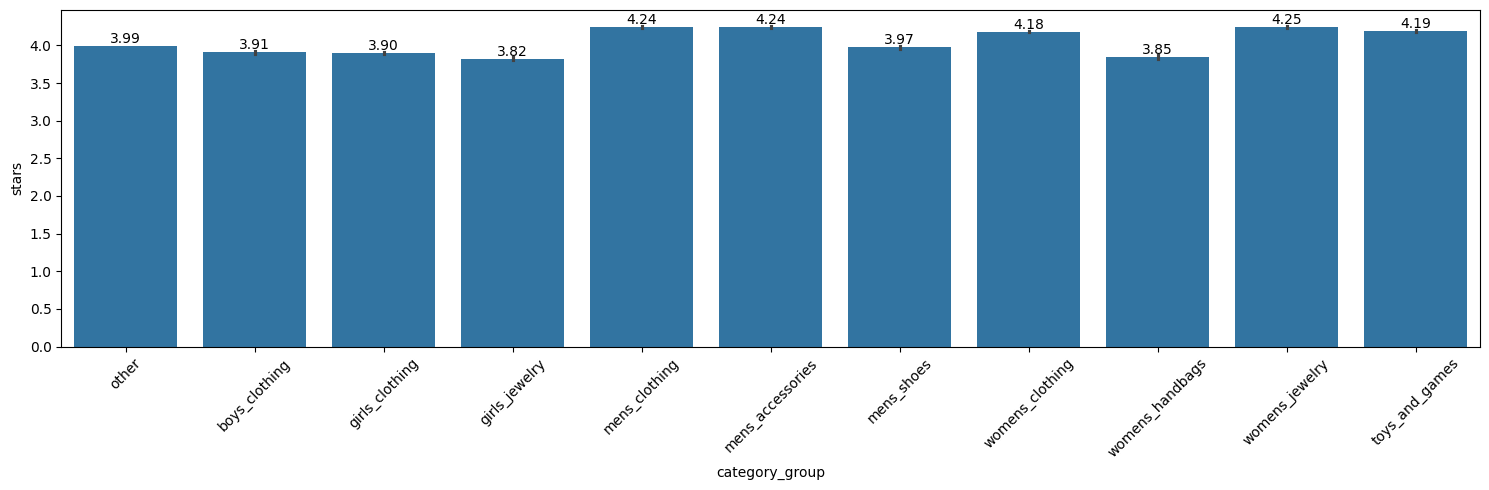

In [ ]:
"""
BAR GRAPH of category_group vs stars
"""
plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="stars", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

In [ ]:
...............start here

"""
BAR GRAPH of category_group vs price
"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="price", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

In [ ]:
"""
BAR GRAPH of category_group vs best_seller %
"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="best_seller", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

In [ ]:
# amzn = amzn_df.drop('category_group', axis='columns')

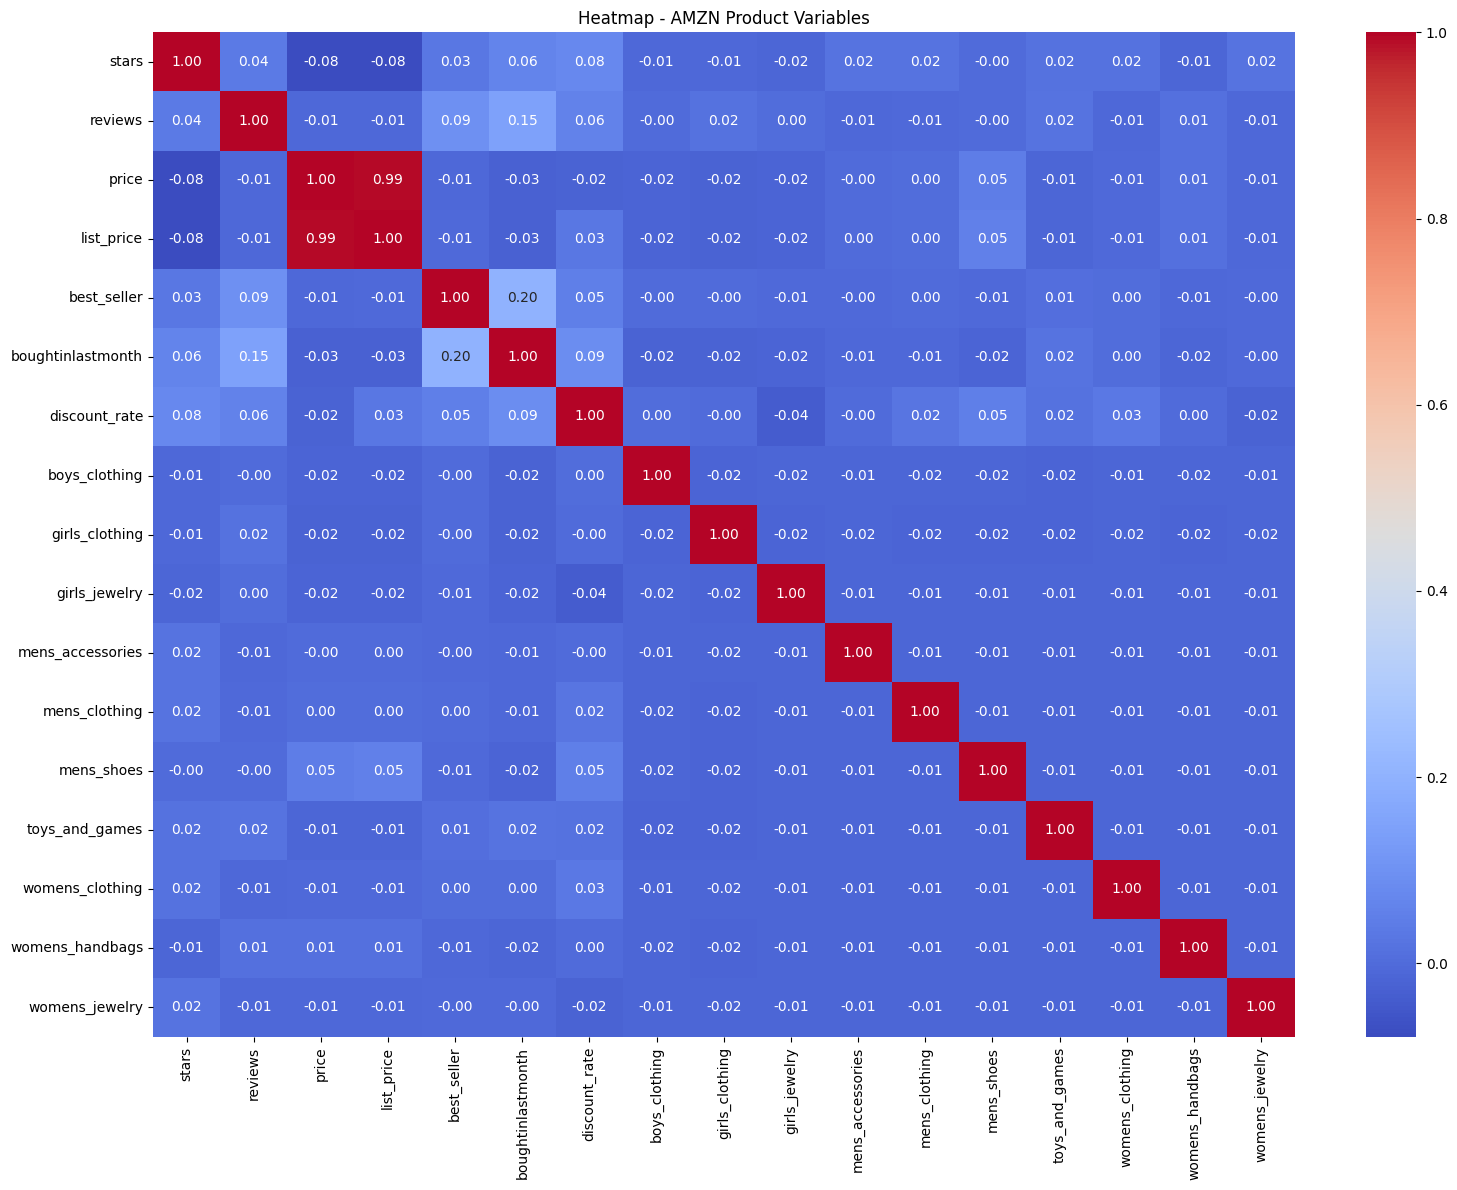

In [ ]:
# Heatmap of variables

# Set seed for reproducibility
np.random.seed(0)

# Correlation matrix
correlation = amzn.corr()

# Plot heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap - AMZN Product Variables")
plt.tight_layout()
plt.show()

In [ ]:
"""
graphs - bar (products & categories):
avg/med price and list_price vs best_seller
avg/med discount amount vs best_seller
avg/med discount percent vs best_seller
quintile variables vs best_seller
binary discount vs % best_seller
binary discount vs stars
"""

NEAREST NEIGHBORS? OTHER TYPES OF MODES?
